In [4]:
import pandas as pd
round_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\round.csv")

round_df = round_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')


print("round:", round_df.shape)
print("\n cols:", list(round_df.columns))
print("\n--- top five  ---")
print(round_df.head())
print("\n--- uniqe name ---")
print(sorted(round_df['name'].dropna().unique()))

round: (9243, 5)

 cols: ['match_id', 'round_id', 'name', 'slug', 'cup_round_type']

--- top five  ---
   match_id  round_id         name         slug  cup_round_type
0  11998445         5  Round of 16  round-of-16             8.0
1  11998446         5  Round of 16  round-of-16             8.0
2  11998447         5  Round of 16  round-of-16             8.0
3  11998448         5  Round of 16  round-of-16             8.0
4  11998449         5  Round of 16  round-of-16             8.0

--- uniqe name ---
['Final', 'Qualification round 1', 'Qualification round 2', 'Quarterfinal', 'Quarterfinals', 'Round of 128', 'Round of 16', 'Round of 32', 'Round of 64', 'Semifinal', 'Semifinals']


In [5]:
finals_df = round_df[round_df['name'] == 'Final'].copy()

print("rows with name=Final:", len(finals_df))
print("uniqe match_id count:", finals_df['match_id'].nunique())
print("duplicated match_id :", finals_df['match_id'].duplicated().sum())

rows with name=Final: 260
uniqe match_id count: 260
duplicated match_id : 0


In [6]:
event_df= pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\event.csv")
home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

event_df = event_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
home_df = home_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
away_df = away_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

event_clean = event_df[['match_id', 'winner_code', 'start_datetime']].dropna(subset=['winner_code'])
home_clean = home_df[['match_id', 'player_id', 'full_name']]
away_clean = away_df[['match_id', 'player_id', 'full_name']]

#keep final matches only
finals_merged = finals_df[['match_id']].merge(event_clean, on='match_id', how='inner')
finals_merged = finals_merged.merge(home_clean, on='match_id', how='inner')
finals_merged = finals_merged.merge(away_clean, on='match_id', how='inner', suffixes=('_home', '_away'))

print("تعداد فینال‌هایی که همه اطلاعاتشون کامله:", len(finals_merged))
print(finals_merged.head())

تعداد فینال‌هایی که همه اطلاعاتشون کامله: 225
   match_id  winner_code  start_datetime  player_id_home      full_name_home  \
0  12002073          1.0      1707051600           64496   Ostapenko, Jelena   
1  12002069          1.0      1707042600          318575     Shnaider, Diana   
2  11998663          1.0      1707012000           79467        Jasika, Omar   
3  11999016          1.0      1707051600          200159     Rodionov, Jurij   
4  12038725          2.0      1707031800          329533  Vilicich, Bautista   

   player_id_away           full_name_away  
0           67759   Alexandrova, Ekaterina  
1           45584                 Zhu, Lin  
2           58369               Bolt, Alex  
3          235576       Nakashima, Brandon  
4          177686  Barranco Cosano, Javier  


In [7]:
import numpy as np

# choose winner 
finals_merged['winner_id'] = np.where(finals_merged['winner_code'] == 1, finals_merged['player_id_home'], finals_merged['player_id_away'])
finals_merged['winner_name'] = np.where(finals_merged['winner_code'] == 1, finals_merged['full_name_home'], finals_merged['full_name_away'])

# تبدیل start_datetime (که یه unix timestamp هست، یعنی ثانیه از 1970) به تاریخ واقعی
finals_merged['match_date'] = pd.to_datetime(finals_merged['start_datetime'], unit='s')
finals_merged['year_month'] = finals_merged['match_date'].dt.to_period('M')

print(finals_merged[['match_id', 'winner_name', 'match_date', 'year_month']].head(10))

   match_id              winner_name          match_date year_month
0  12002073        Ostapenko, Jelena 2024-02-04 13:00:00    2024-02
1  12002069          Shnaider, Diana 2024-02-04 10:30:00    2024-02
2  11998663             Jasika, Omar 2024-02-04 02:00:00    2024-02
3  11999016          Rodionov, Jurij 2024-02-04 13:00:00    2024-02
4  12038725  Barranco Cosano, Javier 2024-02-04 07:30:00    2024-02
5  12038651       Moroni, Gian Marco 2024-02-04 08:30:00    2024-02
6  12039714         Tiurnev, Evgenii 2024-02-04 08:30:00    2024-02
7  12038552            Gengel, Marek 2024-02-04 08:00:00    2024-02
8  12039364         Bouquier, Arthur 2024-02-04 09:55:00    2024-02
9  12039718    Miyazaki, Yuriko Lily 2024-02-04 13:30:00    2024-02


In [8]:
champion_month_counts = finals_merged.groupby(['winner_id', 'winner_name', 'year_month']).size().reset_index(name='titles')
champion_month_counts = champion_month_counts.sort_values('titles', ascending=False)

print(champion_month_counts.head(10))

     winner_id                        winner_name year_month  titles
14       50901                      Popko, Dmitry    2024-02       3
180     372311                       Nicod, Jakub    2024-03       3
124     230049              Jianu, Filip Cristian    2024-03       3
99      202572                      Gengel, Marek    2024-02       3
17       52533                  Jakupovic, Dalila    2024-03       2
40       82133  Dellien Velasco, Murkel Alejandro    2024-02       2
26       63642              Kwiatkowski, Thai-Son    2024-03       2
71      152766                      Helgo, Malene    2024-03       2
100     205282                  Kužmová, Katarína    2024-02       2
154     293708                      Boisson, Loïs    2024-03       2


**QUESTION TEN**

In [9]:
import pandas as pd

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

players = pd.concat([
    home_df[['player_id', 'full_name', 'height', 'current_rank']],
    away_df[['player_id', 'full_name', 'height', 'current_rank']]
], ignore_index=True).drop_duplicates(subset='player_id')

print("تعداد کل بازیکن یکتا:", len(players))
print("\nتعداد null در height:", players['height'].isnull().sum())
print("تعداد null در current_rank:", players['current_rank'].isnull().sum())

print("\n--- آمار توصیفی current_rank ---")
print(players['current_rank'].describe())

تعداد کل بازیکن یکتا: 2644

تعداد null در height: 1327
تعداد null در current_rank: 71

--- آمار توصیفی current_rank ---
count    2573.000000
mean      745.097940
std       454.232715
min         1.000000
25%       343.000000
50%       717.000000
75%      1156.000000
max      1858.000000
Name: current_rank, dtype: float64


In [10]:
players_valid = players.dropna(subset=['height', 'current_rank'])

print("تعداد بازیکنانی که هم height هم rank دارن:", len(players_valid))

correlation = players_valid['height'].corr(players_valid['current_rank'])
print(f"\nضریب همبستگی پیرسون بین height و current_rank: {correlation:.4f}")

تعداد بازیکنانی که هم height هم rank دارن: 1307

ضریب همبستگی پیرسون بین height و current_rank: 0.1051


**QUESTION ELEVEN**

In [12]:
import pandas as pd

time_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\time.csv")

print("قبل از حذف تکراری:", time_df.shape)

time_df = time_df.drop_duplicates()
time_df = time_df.drop_duplicates(subset='match_id', keep='first')

print("بعد از حذف تکراری:", time_df.shape)

قبل از حذف تکراری: (35671, 7)
بعد از حذف تکراری: (16873, 7)


In [13]:
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

for col in period_cols:
    time_df.loc[(time_df[col] < 0) | (time_df[col] < 300), col] = pd.NA

In [18]:
time_df['total_duration'] = time_df[period_cols].sum(axis=1, skipna=True)

# matchهایی که هیچ پریود معتبری ندارن، باید NaN بمونن نه صفر
has_any_period = time_df[period_cols].notnull().any(axis=1)
time_df.loc[~has_any_period, 'total_duration'] = pd.NA

print("تعداد match با مدت‌زمان معتبر (قبل از فیلتر outlier):", time_df['total_duration'].notnull().sum())

تعداد match با مدت‌زمان معتبر (قبل از فیلتر outlier): 10320


In [ ]:
# چک کردن داده مون با ای کیو ای محض اظمینان
Q1 = time_df['total_duration'].quantile(0.25)
Q3 = time_df['total_duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1:.1f} ثانیه")
print(f"Q3 (75%): {Q3:.1f} ثانیه")
print(f"IQR: {IQR:.1f} ثانیه")
print(f"حد بالای مجاز (Q3 + 1.5×IQR): {upper_bound:.1f} ثانیه = {upper_bound/3600:.2f} ساعت")

Q1 (25%): 4633.0 ثانیه
Q3 (75%): 7524.2 ثانیه
IQR: 2891.2 ثانیه
حد بالای مجاز (Q3 + 1.5×IQR): 11861.1 ثانیه = 3.29 ساعت


In [19]:
MAX_REALISTIC_DURATION = 21600  # 6 ساعت

time_df_clean = time_df[
    time_df['total_duration'].isnull() | (time_df['total_duration'] <= MAX_REALISTIC_DURATION)
].copy()

removed_count = time_df['total_duration'].notnull().sum() - time_df_clean['total_duration'].notnull().sum()
print(f"تعداد matchهای حذف‌شده به‌خاطر مدت‌زمان غیرممکن: {removed_count}")

تعداد matchهای حذف‌شده به‌خاطر مدت‌زمان غیرممکن: 88


In [20]:
print("\n--- آمار توصیفی نهایی total_duration (ثانیه) ---")
print(time_df_clean['total_duration'].describe())

avg_duration_sec = time_df_clean['total_duration'].mean()
avg_duration_min = avg_duration_sec / 60

print(f"\nمیانگین نهایی مدت‌زمان match: {avg_duration_sec:.1f} ثانیه (= {avg_duration_min:.1f} دقیقه)")


--- آمار توصیفی نهایی total_duration (ثانیه) ---
count    10232.000000
mean      6198.595778
std       2189.118528
min       1130.000000
25%       4623.000000
50%       5787.000000
75%       7475.000000
max      21338.000000
Name: total_duration, dtype: float64

میانگین نهایی مدت‌زمان match: 6198.6 ثانیه (= 103.3 دقیقه)


**QUESTION 12**

In [1]:
import pandas as pd

home_score_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team_score.csv")
away_score_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team_score.csv")

print("شکل home_score:", home_score_df.shape)
print("ستون‌ها:", list(home_score_df.columns))
print("\n--- ۵ ردیف اول ---")
print(home_score_df.head())

شکل home_score: (35164, 14)
ستون‌ها: ['match_id', 'current_score', 'display_score', 'period_1', 'period_2', 'period_3', 'period_4', 'period_5', 'period_1_tie_break', 'period_2_tie_break', 'period_3_tie_break', 'period_4_tie_break', 'period_5_tie_break', 'normal_time']

--- ۵ ردیف اول ---
   match_id  current_score  display_score  period_1  period_2  period_3  \
0  11974053            3.0            3.0       NaN       NaN       NaN   
1  11974066            0.0            0.0       NaN       NaN       NaN   
2  11998445            1.0            1.0       5.0       6.0       6.0   
3  11998446            0.0            0.0       4.0       1.0       NaN   
4  11998447            2.0            2.0       6.0       6.0       NaN   

   period_4  period_5  period_1_tie_break  period_2_tie_break  \
0       NaN       NaN                 NaN                 NaN   
1       NaN       NaN                 NaN                 NaN   
2       NaN       NaN                 NaN                 NaN   


In [3]:
home_score_df = home_score_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
away_score_df = away_score_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

print("home_score بعد از تمیزکاری:", home_score_df.shape)
print("away_score بعد از تمیزکاری:", away_score_df.shape)

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
home_df = home_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

print("\n--- مقادیر یکتای gender ---")
print(home_df['gender'].value_counts(dropna=False))

home_score بعد از تمیزکاری: (16873, 14)
away_score بعد از تمیزکاری: (16873, 14)

--- مقادیر یکتای gender ---
gender
M      7116
F      5254
NaN      19
Name: count, dtype: int64


In [4]:
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

# فقط ستون‌های لازم رو نگه می‌داریم
home_score_clean = home_score_df[['match_id'] + period_cols].copy()
away_score_clean = away_score_df[['match_id'] + period_cols].copy()

# وصل کردن home و away بر اساس match_id (هر ستون period جدا برای home و away)
scores_merged = home_score_clean.merge(away_score_clean, on='match_id', suffixes=('_home', '_away'))

# برای هر ست، گیم‌های home+away رو جمع می‌زنیم
for i in range(1, 6):
    scores_merged[f'set{i}_total_games'] = scores_merged[f'period_{i}_home'] + scores_merged[f'period_{i}_away']

# اضافه کردن gender بر اساس match_id
gender_lookup = home_df[['match_id', 'gender']]
scores_merged = scores_merged.merge(gender_lookup, on='match_id', how='left')

print(scores_merged[['match_id', 'gender', 'set1_total_games', 'set2_total_games', 'set3_total_games']].head())

   match_id gender  set1_total_games  set2_total_games  set3_total_games
0  11974053    NaN               NaN               NaN               NaN
1  11974066    NaN               NaN               NaN               NaN
2  11998445      M              12.0               8.0              13.0
3  11998446      M              10.0               7.0               NaN
4  11998447      M              10.0               6.0               NaN


In [5]:
# فقط ستون‌های لازم رو نگه می‌داریم
set_cols = ['set1_total_games', 'set2_total_games', 'set3_total_games', 'set4_total_games', 'set5_total_games']

long_df = scores_merged.melt(
    id_vars=['match_id', 'gender'],
    value_vars=set_cols,
    var_name='set_number',
    value_name='total_games'
)

# حذف ردیف‌هایی که اون ست اصلاً بازی نشده (NaN) یا gender نامشخصه
long_df = long_df.dropna(subset=['total_games', 'gender'])

print("تعداد کل ست‌های معتبر:", len(long_df))
print(long_df.head())

# میانگین گیم به‌ازای هر ست، جدا برای مرد و زن
avg_by_gender = long_df.groupby('gender')['total_games'].agg(['mean', 'count', 'std'])
print("\n--- میانگین تعداد گیم در هر ست، به تفکیک جنسیت ---")
print(avg_by_gender)

تعداد کل ست‌های معتبر: 25001
   match_id gender        set_number  total_games
2  11998445      M  set1_total_games         12.0
3  11998446      M  set1_total_games         10.0
4  11998447      M  set1_total_games         10.0
5  11998448      M  set1_total_games         10.0
6  11998449      M  set1_total_games          7.0

--- میانگین تعداد گیم در هر ست، به تفکیک جنسیت ---
            mean  count       std
gender                           
F       9.207060  10736  2.458121
M       9.586961  14265  2.497284


**QUESTION 13**

In [6]:
import pandas as pd

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

players = pd.concat([
    home_df[['player_id', 'full_name', 'plays']],
    away_df[['player_id', 'full_name', 'plays']]
], ignore_index=True).drop_duplicates(subset='player_id')

print("تعداد کل بازیکن یکتا:", len(players))
print("\nتعداد null در plays:", players['plays'].isnull().sum())

print("\n--- مقادیر یکتای plays ---")
print(players['plays'].value_counts(dropna=False))

تعداد کل بازیکن یکتا: 2644

تعداد null در plays: 1498

--- مقادیر یکتای plays ---
plays
NaN             1498
right-handed    1013
left-handed      133
Name: count, dtype: int64


In [7]:
# فقط بازیکنانی که plays معتبر دارن
players_valid = players.dropna(subset=['plays'])

print("تعداد بازیکنانی که اطلاعات دست‌برتری دارن:", len(players_valid))

hand_counts = players_valid['plays'].value_counts()
hand_percent = players_valid['plays'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'count': hand_counts,
    'percent': hand_percent.round(1)
})

print("\n--- توزیع دست‌برتری (فقط بازیکنان با اطلاعات معتبر) ---")
print(summary)

تعداد بازیکنانی که اطلاعات دست‌برتری دارن: 1146

--- توزیع دست‌برتری (فقط بازیکنان با اطلاعات معتبر) ---
              count  percent
plays                       
right-handed   1013     88.4
left-handed     133     11.6


C:\Users\Personal Camputer\AppData\Local\Temp\ipykernel_43772\2407070755.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=hand_counts.index, y=hand_counts.values, palette=['#4C72B0', '#DD8452'])


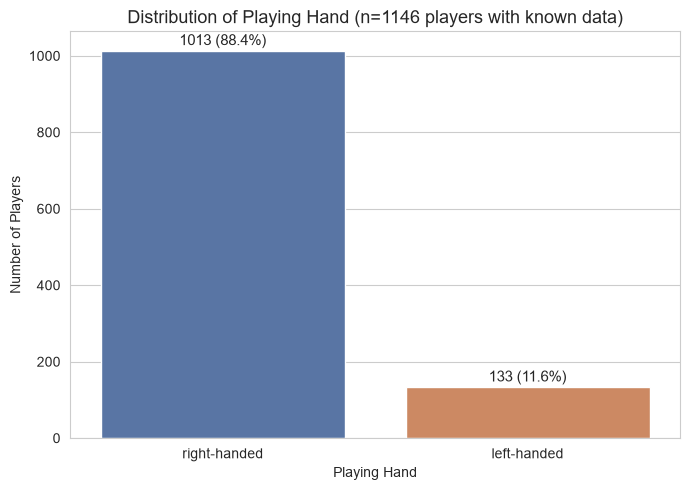

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

ax = sns.barplot(x=hand_counts.index, y=hand_counts.values, palette=['#4C72B0', '#DD8452'])

for i, v in enumerate(hand_counts.values):
    pct = hand_percent.values[i]
    ax.text(i, v + 15, f"{v} ({pct:.1f}%)", ha='center', fontsize=11)

plt.title(f"Distribution of Playing Hand (n={len(players_valid)} players with known data)", fontsize=13)
plt.xlabel("Playing Hand")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

**QUESTION 14**

In [10]:
import pandas as pd

tournament_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\tournament.csv")

print("شکل tournament:", tournament_df.shape)
print("ستون‌ها:", list(tournament_df.columns))

print("\nتعداد null در ground_type:", tournament_df['ground_type'].isnull().sum())
print("\n--- مقادیر یکتای ground_type ---")
print(tournament_df['ground_type'].value_counts(dropna=False))

شکل tournament: (35671, 16)
ستون‌ها: ['match_id', 'tournament_id', 'tournament_name', 'tournament_slug', 'tournament_unique_id', 'tournament_category_name', 'tournament_category_slug', 'user_count', 'ground_type', 'tennis_points', 'has_event_player_statistics', 'crowd_sourcing_enabled', 'has_performance_graph_feature', 'display_inverse_home_away_teams', 'priority', 'competition_type']

تعداد null در ground_type: 562

--- مقادیر یکتای ground_type ---
ground_type
Hardcourt outdoor    16959
Red clay             11856
Hardcourt indoor      4741
NaN                    562
Red clay indoor        512
Grass                  509
Carpet indoor          276
Synthetic outdoor      226
Green clay              30
Name: count, dtype: int64


In [11]:
# اول تکراری‌ها رو تمیز می‌کنیم (طبق همون الگوی همیشگی)
tournament_df = tournament_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

print("بعد از تمیزکاری:", tournament_df.shape)

# دیدگاه ۱: بر اساس تعداد match (هر match یه رای برای سطح زمینش)
print("\n--- توزیع بر اساس تعداد match ---")
match_level = tournament_df['ground_type'].value_counts(dropna=True)
print(match_level)
print(f"\nمتداول‌ترین (بر اساس match): {match_level.index[0]} با {match_level.iloc[0]} match")

# دیدگاه ۲: بر اساس تعداد تورنمنت یکتا (هر تورنمنت فقط یه بار حساب میشه)
tournaments_unique = tournament_df.drop_duplicates(subset='tournament_id')
print("\nتعداد تورنمنت یکتا:", len(tournaments_unique))

print("\n--- توزیع بر اساس تعداد تورنمنت یکتا ---")
tournament_level = tournaments_unique['ground_type'].value_counts(dropna=True)
print(tournament_level)
print(f"\nمتداول‌ترین (بر اساس تورنمنت یکتا): {tournament_level.index[0]} با {tournament_level.iloc[0]} تورنمنت")

بعد از تمیزکاری: (16873, 16)

--- توزیع بر اساس تعداد match ---
ground_type
Hardcourt outdoor    8116
Red clay             5609
Hardcourt indoor     2172
Grass                 242
Red clay indoor       218
Carpet indoor         126
Synthetic outdoor      99
Green clay             18
Name: count, dtype: int64

متداول‌ترین (بر اساس match): Hardcourt outdoor با 8116 match

تعداد تورنمنت یکتا: 535

--- توزیع بر اساس تعداد تورنمنت یکتا ---
ground_type
Hardcourt outdoor    239
Red clay             184
Hardcourt indoor      83
Red clay indoor        6
Grass                  6
Carpet indoor          5
Synthetic outdoor      3
Green clay             1
Name: count, dtype: int64

متداول‌ترین (بر اساس تورنمنت یکتا): Hardcourt outdoor با 239 تورنمنت
